**Bagging** (short for **Bootstrap Aggregating**) is an ensemble learning meta-algorithm designed to reduce the variance of high-variance, low-bias base estimators (such as unpruned decision trees) without increasing their bias.

---

### Core Mechanics of Bagging

```
Original Dataset (N samples)
   ├── Bootstrap Sample 1 (N samples with replacement) ──► Base Model 1 ┐
   ├── Bootstrap Sample 2 (N samples with replacement) ──► Base Model 2 ┼─► Aggregation (Vote / Average) ──► Final Output
   └── Bootstrap Sample B (N samples with replacement) ──► Base Model B ┘

```

1. **Bootstrap Sampling:** For a dataset of size $N$, $B$ independent bootstrap datasets are created by sampling $N$ instances uniformly **with replacement**. Mathematically, each sample has a probability of $(1 - 1/N)^N \approx 1/e \approx 0.368$ of being omitted from a given bootstrap set. These omitted samples (~36.8%) form the **Out-of-Bag (OOB)** set.
2. **Parallel Base Training:** $B$ independent base models $f_1(x), f_2(x), \dots, f_B(x)$ are fitted in parallel on each bootstrap subset.
3. **Aggregation:**
* **Regression:** Simple arithmetic mean of individual outputs:

$$\hat{f}_{bag}(x) = \frac{1}{B} \sum_{b=1}^{B} f_b(x)$$


* **Classification:** Majority voting across predicted classes, or averaging predicted probability vectors (soft voting):

$$\hat{y}_{bag} = \arg\max_{c} \sum_{b=1}^{B} I(f_b(x) = c)$$





---

### Popular Bagging Variants

| Algorithm | Base Estimator | Sampling Method | Feature Subspace Randomness |
| --- | --- | --- | --- |
| **Standard Bagging** | Decision Trees, KNN, etc. | Bootstrap with replacement | Uses all $p$ features |
| **Random Forest** | Deep Decision Trees | Bootstrap with replacement | Random subset of $m \approx \sqrt{p}$ features at each node split |
| **Extra Trees** | Deep Decision Trees | Bootstrap or full dataset | Random feature subset + random split thresholds |
| **Pasting** | Any base model | Sampling **without** replacement | Uses all $p$ features |
| **Random Subspaces** | Any base model | Full instance dataset | Samples random feature subsets |
| **Random Patches** | Any base model | Bootstrap instances | Samples random feature subsets |

---

# Jupyter Notebook: Exploring & Implementing Bagging Algorithms


In [1]:
# Environment & Library Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier

# Set random seed for reproducibility
np.random.seed(42)

### What this code does
This cell imports the libraries needed for data handling, plotting, and ensemble learning. It loads NumPy, pandas, matplotlib, the moons dataset generator, train/test splitting utilities, and the bagging/tree classifiers used later. The random seed keeps the results consistent across runs.


In [2]:
# Generate Synthetic Dataset
# Moons dataset introduces non-linear decision boundaries with noise
X, y = make_moons(n_samples=1500, noise=0.35, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training instances: {X_train.shape[0]} | Test instances: {X_test.shape[0]}")

Training instances: 1050 | Test instances: 450


### What this code does
This cell creates a synthetic two-moons dataset with some noise to produce a non-linear classification problem. It then splits the data into training and test sets and prints the number of samples in each split so the models can be evaluated fairly.


In [3]:
# Train & Compare Base Tree vs. Bagging Variants
models = {
    "Single Deep Decision Tree": DecisionTreeClassifier(random_state=42),
    "Standard Bagging (100 Trees)": BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=100,
        max_samples=1.0,
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    ),
    "Random Forest (100 Trees)": RandomForestClassifier(
        n_estimators=100,
        max_features="sqrt",
        oob_score=True,
        random_state=42,
        n_jobs=-1
    ),
    "Extra Trees (100 Trees)": ExtraTreesClassifier(
        n_estimators=100,
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )
}

# Evaluate performance
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    # Extract OOB Score if available
    oob = getattr(model, "oob_score_", None)
    oob_str = f"{oob:.4f}" if oob is not None else "N/A"
    
    results.append({"Model": name, "Test Accuracy": f"{acc:.4f}", "OOB Score": oob_str})

# Display summary table
results_df = pd.DataFrame(results)
results_df

,Model,Test Accuracy,OOB Score
0,Single Deep Decision Tree,0.8222,N/A
1,Standard Bagging (100 Trees),0.8578,0.8676
2,Random Forest (100 Trees),0.8644,0.8676
3,Extra Trees (100 Trees),0.8756,0.8733


### What this code does
This code builds several models: a single decision tree, a standard bagging classifier, a random forest, and an extra trees classifier. Each model is trained on the same data, evaluated on the test set, and the results are summarized in a table showing accuracy and out-of-bag score when available.


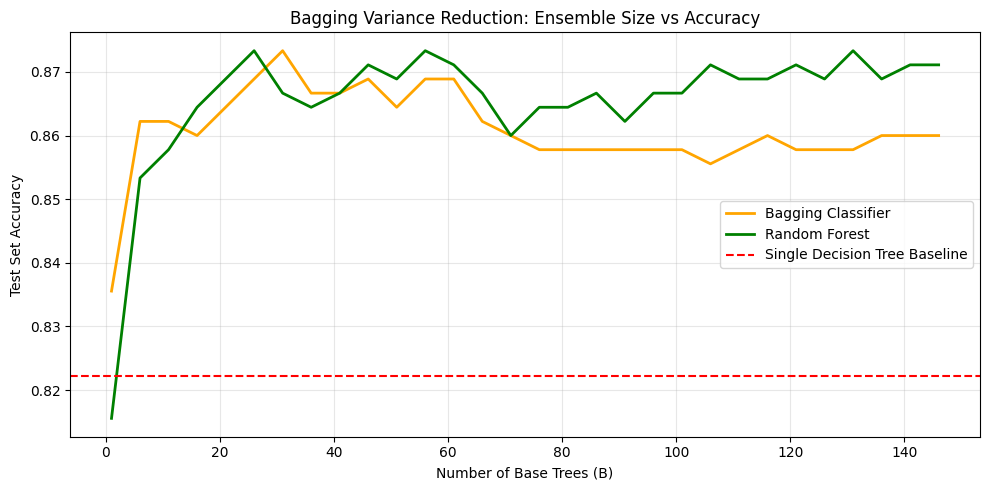

In [4]:
# Analyze Ensemble Convergence (Trees vs. Test Accuracy)
# Shows how increasing ensemble size (B) stabilizes and improves accuracy
tree_counts = range(1, 151, 5)
bagging_accs = []
rf_accs = []

for n_trees in tree_counts:
    # Evaluate Standard Bagging
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=n_trees,
        random_state=42,
        n_jobs=-1
    ).fit(X_train, y_train)
    bagging_accs.append(accuracy_score(y_test, bag.predict(X_test)))
    
    # Evaluate Random Forest
    rf = RandomForestClassifier(
        n_estimators=n_trees,
        random_state=42,
        n_jobs=-1
    ).fit(X_train, y_train)
    rf_accs.append(accuracy_score(y_test, rf.predict(X_test)))

# Plot convergence curves
plt.figure(figsize=(10, 5))
plt.plot(tree_counts, bagging_accs, label="Bagging Classifier", color="orange", lw=2)
plt.plot(tree_counts, rf_accs, label="Random Forest", color="green", lw=2)
plt.axhline(
    y=accuracy_score(y_test, models["Single Deep Decision Tree"].predict(X_test)),
    color="red", linestyle="--", label="Single Decision Tree Baseline"
)

plt.title("Bagging Variance Reduction: Ensemble Size vs Accuracy")
plt.xlabel("Number of Base Trees (B)")
plt.ylabel("Test Set Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What this code does
This section measures how ensemble performance changes as the number of trees increases. It fits bagging and random forest models with different tree counts and plots accuracy versus ensemble size, helping to visualize the stability gains that come from averaging many weak learners.


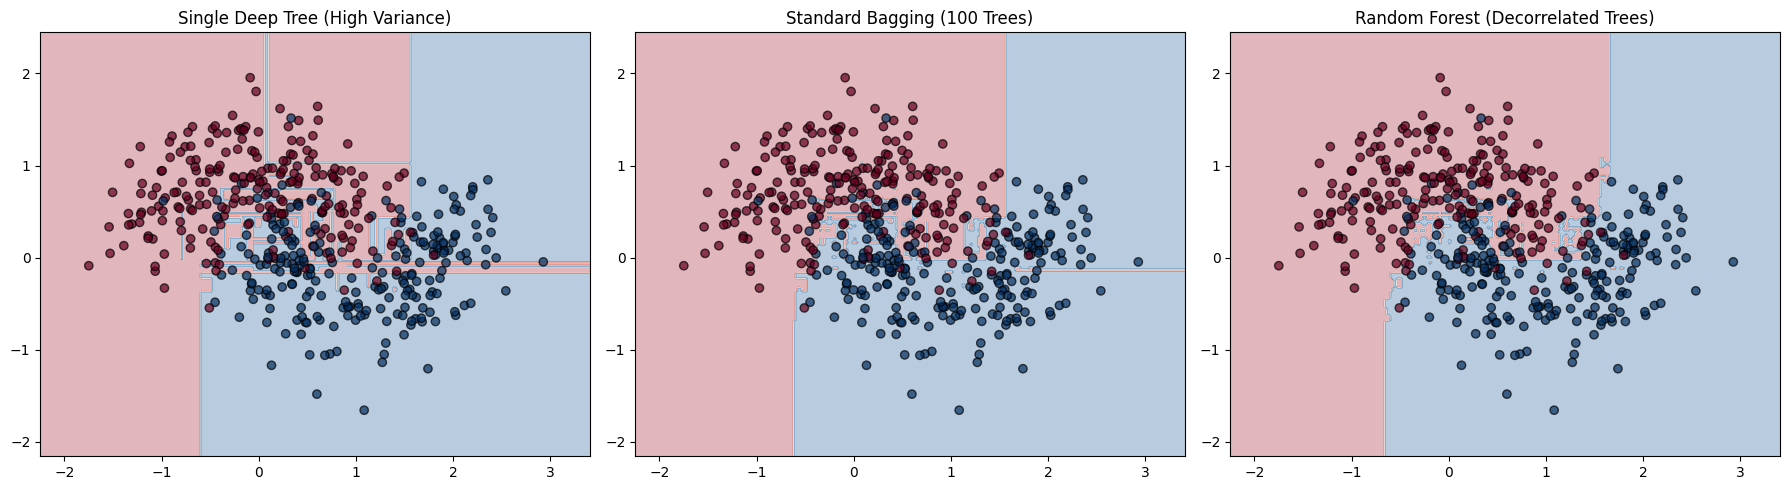

In [5]:
# Visualize Decision Boundaries
# Demonstrates how bagging smooths complex decision boundaries
def plot_decision_boundary(clf, X, y, title, ax):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolors='k', alpha=0.7)
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_decision_boundary(models["Single Deep Decision Tree"], X_test, y_test, "Single Deep Tree (High Variance)", axes[0])
plot_decision_boundary(models["Standard Bagging (100 Trees)"], X_test, y_test, "Standard Bagging (100 Trees)", axes[1])
plot_decision_boundary(models["Random Forest (100 Trees)"], X_test, y_test, "Random Forest (Decorrelated Trees)", axes[2])

plt.tight_layout()
plt.show()

### What this code does
This final visualization creates a decision-boundary plot for each model by evaluating predictions across a grid of input values. The resulting subplot shows how a single deep tree overfits the training data while bagging and random forest produce smoother, more stable boundaries.
